In [1]:
####Importer les bibliothèques nécessaire  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
##Charger les données

df = pd.read_csv("SuperMarket Analysis.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [11]:
###Comprendre les données 
###nombre de lignes, type des variables, valeurs manquantes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [17]:
###Statistiques de base 
    #moyenne
    
    #minimum
    
    #maximum
    
    #écart type
 

df.describe

<bound method NDFrame.describe of       Invoice ID Branch       City Customer type  Gender  \
0    750-67-8428   Alex     Yangon        Member  Female   
1    226-31-3081   Giza  Naypyitaw        Normal  Female   
2    631-41-3108   Alex     Yangon        Normal  Female   
3    123-19-1176   Alex     Yangon        Member  Female   
4    373-73-7910   Alex     Yangon        Member  Female   
..           ...    ...        ...           ...     ...   
995  233-67-5758   Giza  Naypyitaw        Normal    Male   
996  303-96-2227  Cairo   Mandalay        Normal  Female   
997  727-02-1313   Alex     Yangon        Member    Male   
998  347-56-2442   Alex     Yangon        Normal    Male   
999  849-09-3807   Alex     Yangon        Member  Female   

               Product line  Unit price  Quantity   Tax 5%      Sales  \
0         Health and beauty       74.69         7  26.1415   548.9715   
1    Electronic accessories       15.28         5   3.8200    80.2200   
2        Home and lifestyl

In [19]:
###Vérifier les valeurs manquantes

df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [27]:
##Chiffre d'affaires total

total_sales = df["Sales"].sum()
print("Total des ventes :", total_sales)

Total des ventes : 322966.749


In [25]:
print(df.columns)

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')


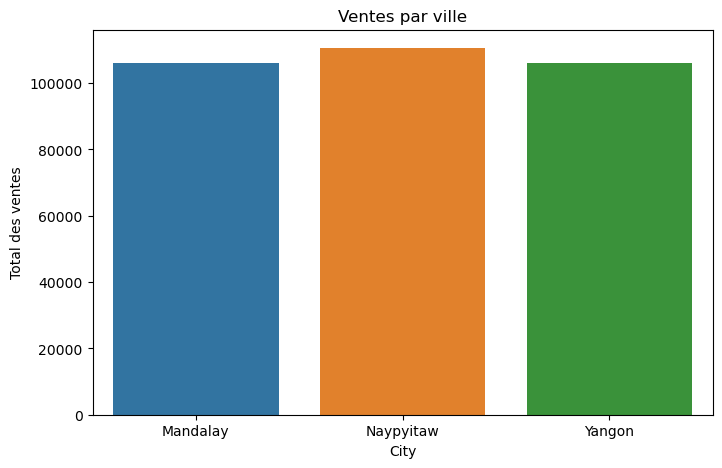

In [37]:
###Ventes par ville

sales_city = df.groupby("City")["Sales"].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=sales_city.index, y=sales_city.values)
plt.title("Ventes par ville")
plt.ylabel("Total des ventes")
plt.show()

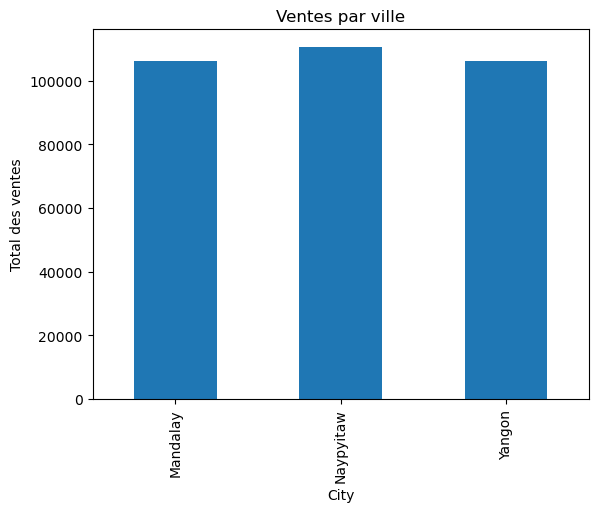

In [31]:
###Graphique ventes par ville

sales_city.plot(kind="bar", title="Ventes par ville")
plt.ylabel("Total des ventes")
plt.show()

In [33]:
###Produits les plus vendus

product_sales = df.groupby("Product line")["Sales"].sum()
product_sales.sort_values(ascending=False)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64

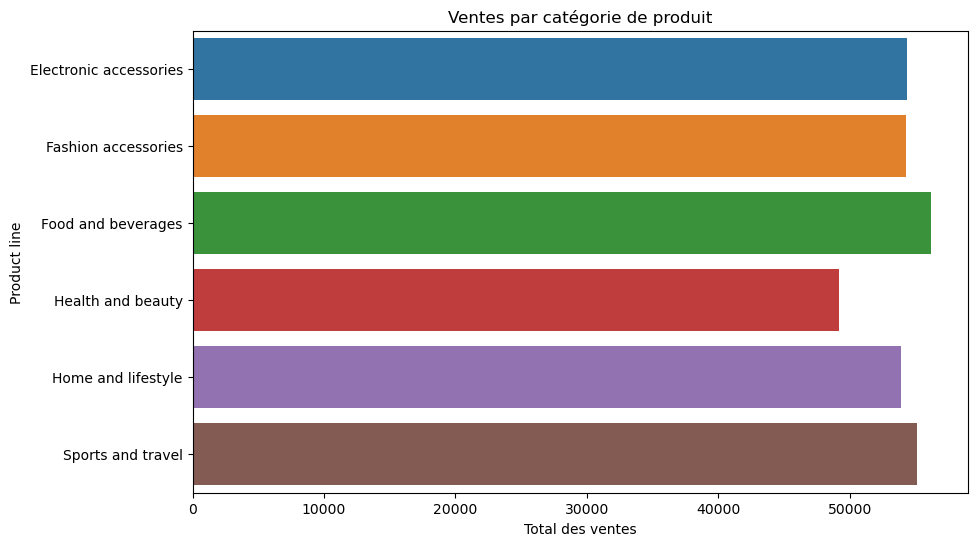

In [35]:
###Graphique produits

plt.figure(figsize=(10,6))
sns.barplot(x=product_sales.values, y=product_sales.index)
plt.title("Ventes par catégorie de produit")
plt.xlabel("Total des ventes")
plt.show()

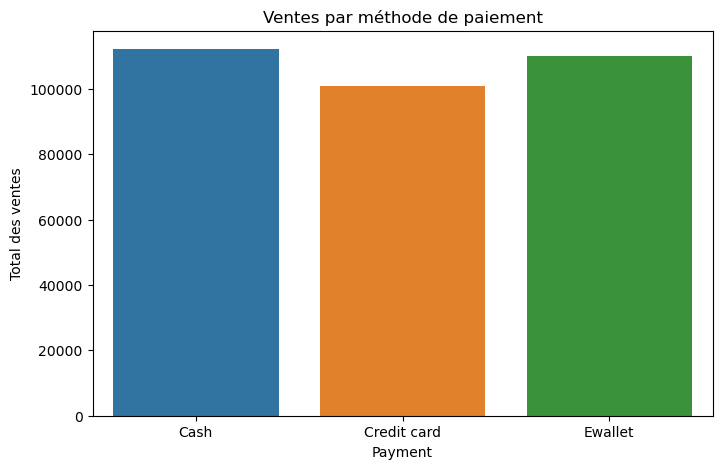

In [39]:
#######Méthode de paiement la plus utilisée

payment_sales = df.groupby("Payment")["Sales"].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=payment_sales.index, y=payment_sales.values)
plt.title("Ventes par méthode de paiement")
plt.ylabel("Total des ventes")
plt.show()

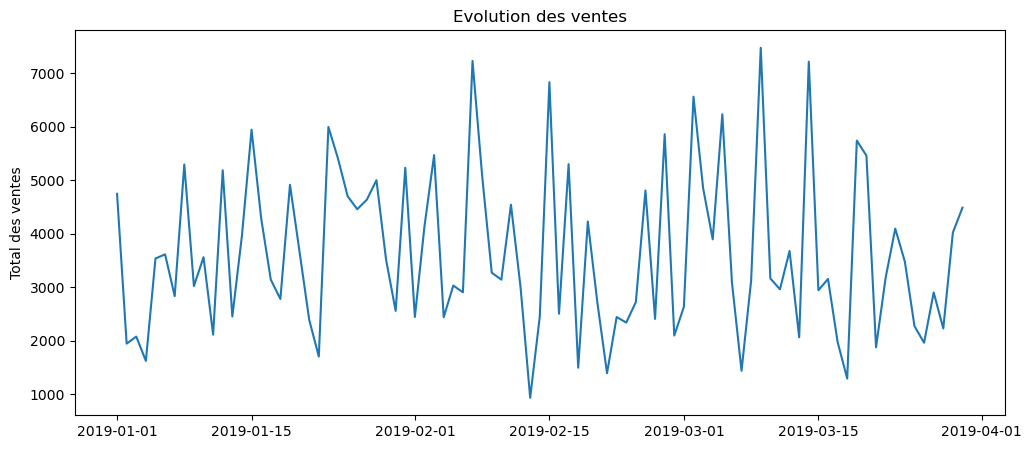

In [43]:
##Évolution des ventes dans le temps

df["Date"] = pd.to_datetime(df["Date"])

sales_date = df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(sales_date)
plt.title("Evolution des ventes")
plt.ylabel("Total des ventes")
plt.show()